## 1. Dependencies

In [8]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))




CUDA available: True
GPU: NVIDIA RTX A6000


In [7]:
import subprocess

UV = '/data/ryanschen/.local/bin/uv'  

packages = [
    'OpenNMT-py==2.2.0',
    'safe-mol',
    'rdkit',
    'pandas',
    'tqdm',
]
subprocess.run([UV, 'pip', 'install'] + packages, check=True)

Using Python 3.11.15 environment at: saferetrouv
Resolved 114 packages in 817ms
 Downloaded sentencepiece
 Downloaded tensorboard
 Downloaded tensorboard-data-server
 Downloaded grpcio
 Downloaded pyonmttok
Prepared 15 packages in 1.83s
Installed 15 packages in 503ms
 + absl-py==2.4.0
 + blinker==1.9.0
 + configargparse==1.7.5
 + flask==3.1.3
 + grpcio==1.80.0
 + itsdangerous==2.2.0
 + markdown==3.10.2
 + opennmt-py==2.2.0
 + pyonmttok==1.38.1
 + sentencepiece==0.2.1
 + tensorboard==2.20.0
 + tensorboard-data-server==0.7.2
 + torchtext==0.5.0
 + waitress==3.0.2
 + werkzeug==3.1.8


CompletedProcess(args=['/data/ryanschen/.local/bin/uv', 'pip', 'install', 'OpenNMT-py==2.2.0', 'safe-mol', 'rdkit', 'pandas', 'tqdm'], returncode=0)

In [9]:
# Importing libraries after installation

import os
import re
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

import safe as sf
from rdkit import Chem

/data/ryanschen/safe-retro/saferetrouv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Loading SAFE Dataset

In [25]:
DATA_DIR   = '/data/ryanschen/safe-retro/Data'  
TRAIN_FILE = 'train_safe.csv'
VAL_FILE   = 'val_safe.csv'
TEST_FILE  = 'test_safe.csv'

SRC_COL = 'safe_products'    # encoder input
TGT_COL = 'safe_precursors'  # decoder target

def load_file(path):
    return pd.read_csv(path)

def split_safe_reaction(df):
    split = df['safe'].str.split('>>', expand=True)
    df['safe_precursors'] = split[0]
    df['safe_products']   = split[1]
    return df

train_df = split_safe_reaction(load_file(os.path.join(DATA_DIR, TRAIN_FILE)))
val_df   = split_safe_reaction(load_file(os.path.join(DATA_DIR, VAL_FILE)))
test_df  = split_safe_reaction(load_file(os.path.join(DATA_DIR, TEST_FILE)))

print(f'Train : {len(train_df):,} reactions')
print(f'Val   : {len(val_df):,} reactions')
print(f'Test  : {len(test_df):,} reactions')
train_df[[SRC_COL, TGT_COL]].head(3)

Train : 409,006 reactions
Val   : 29,998 reactions
Test  : 39,994 reactions


,safe_products,safe_precursors
0,c12ccc(O)nc1.CC(C)CC2=O,C1CCOC1~CC(C)C[Mg+]~c12ccc(O)nc1.CON(C)C2=O~[Cl-]
1,c12ccc3cc1[N+](=O)[O-].C3(=O)O.CN2,CN~O~c12ccc(Cl)c([N+](=O)[O-])c1.O=C2O
2,n16cc5c(=O)c2cc(F)c7cc21.c17ccc4cc1.C5(=O)O.N4...,n15cc4c(=O)c2cc(F)c6cc21.c16ccc(N)cc1.C4(=O)O....


In [ ]:
# Fragment Rate Check
n_safe_src = train_df[SRC_COL].str.contains('~').sum()
n_safe_tgt = train_df[TGT_COL].str.contains('~').sum()
print(f'Products with SAFE fragments: {n_safe_src:,} / {len(train_df):,} ({n_safe_src/len(train_df)*100:.1f}%)')
print(f'Precursors with SAFE fragments: {n_safe_tgt:,} / {len(train_df):,} ({n_safe_tgt/len(train_df)*100:.1f}%)')

Products  with SAFE fragments: 4,863 / 409,006 (1.2%)
Precursors with SAFE fragments: 409,006 / 409,006 (100.0%)


In [ ]:
# Round Trip Decode
def safe_to_canonical(safe_str: str) -> str:
    try:
        pieces = safe_str.split('~')
        decoded = []
        for piece in pieces:
            mol = sf.decode(piece.strip(), as_mol=True, ignore_errors=True)
            if mol is None:
                return ''
            decoded.append(Chem.MolToSmiles(mol))
        return '.'.join(decoded)
    except Exception:
        return ''

# Sanity Check
N_CHECK = 5
print('Sample round-trip check (SAFE → SMILES):')
for safe_str in train_df[SRC_COL].head(N_CHECK):
    result = safe_to_canonical(safe_str)
    status = '✓' if result != '' else '✗'
    print(f'  {status}  {safe_str[:60]}  →  {result[:60]}')

Sample round-trip check (SAFE → SMILES):
  ✓  c12ccc(O)nc1.CC(C)CC2=O  →  CC(C)CC(=O)c1ccc(O)nc1
  ✓  c12ccc3cc1[N+](=O)[O-].C3(=O)O.CN2  →  CNc1ccc(C(=O)O)cc1[N+](=O)[O-]
  ✓  n16cc5c(=O)c2cc(F)c7cc21.c17ccc4cc1.C5(=O)O.N4C=O.CC6  →  CCn1cc(C(=O)O)c(=O)c2cc(F)c(-c3ccc(NC=O)cc3)cc21
  ✓  c1%10cc%11cc5c1.c19cnc%13cn1.c1%12cnc(C)cn1.C7C8C.N14CCC1.C4  →  COCC(C)Oc1cc(Oc2cnc(C(=O)N3CCC3)cn2)cc(C(=O)Nc2cnc(C)cn2)c1
  ✓  Clc1cc2c5nc7nc2s1.c16ccc(Cl)c(Cl)c1.c17ccncc1.N45.C46  →  Clc1cc2c(NCc3ccc(Cl)c(Cl)c3)nc(-c3ccncc3)nc2s1


# 3. Tokenization

In [31]:
SMI_REGEX_PATTERN = (
    r'(\%\([0-9]{3}\)|\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p'
    r'|\||\(|\)|\.|=|#|-|\+|\\|\/|:|~|@|\?|>>?|\*|\$|\%[0-9]{2}|[0-9])'
)
regular_expression = re.compile(SMI_REGEX_PATTERN)

def tokenize(smiles: str) -> str:
    return ' '.join(regular_expression.findall(smiles))

# Quick check of tokenization
example = train_df[SRC_COL].iloc[0]
print('Original :', example)
print('Tokenized:', tokenize(example))

Original : c12ccc(O)nc1.CC(C)CC2=O
Tokenized: c 1 2 c c c ( O ) n c 1 . C C ( C ) C C 2 = O


In [ ]:
# Tokenization of Training Sets

print('Tokenizing training set...')
train_df['tok_src'] = train_df[SRC_COL].progress_apply(tokenize)
train_df['tok_tgt'] = train_df[TGT_COL].progress_apply(tokenize)

print('Tokenizing validation set...')
val_df['tok_src'] = val_df[SRC_COL].progress_apply(tokenize)
val_df['tok_tgt'] = val_df[TGT_COL].progress_apply(tokenize)

print('Tokenizing test set...')
test_df['tok_src'] = test_df[SRC_COL].progress_apply(tokenize)
test_df['tok_tgt'] = test_df[TGT_COL].progress_apply(tokenize)

print('Done.')

# Quick check — show a tokenized example
print('\nExample:')
print('SRC:', train_df['tok_src'].iloc[0][:100], '...')
print('TGT:', train_df['tok_tgt'].iloc[0][:100], '...')


Tokenizing training set...


100%|██████████| 409006/409006 [00:02<00:00, 163494.63it/s]


Tokenizing validation set...


100%|██████████| 29998/29998 [00:00<00:00, 173229.72it/s]


Tokenizing test set...


100%|██████████| 39994/39994 [00:00<00:00, 170459.17it/s]

Done.

Example:
SRC: c 1 2 c c c ( O ) n c 1 . C C ( C ) C C 2 = O ...
TGT: C 1 C C O C 1 ~ C C ( C ) C [Mg+] ~ c 1 2 c c c ( O ) n c 1 . C O N ( C ) C 2 = O ~ [Cl-] ...


In [33]:
# Saving the tokenized datasets for later use

DATA_OUT = 'USPTO_SAFE_preprocessed'
os.makedirs(DATA_OUT, exist_ok=True)

train_shuffled = train_df.sample(frac=1.0, random_state=42)

splits = {
    'train': train_shuffled,
    'val'  : val_df,
    'test' : test_df,
}

for split_name, df in splits.items():
    for col, fname in [('tok_src', f'src-{split_name}.txt'),
                       ('tok_tgt', f'tgt-{split_name}.txt')]:
        path = os.path.join(DATA_OUT, fname)
        with open(path, 'w') as f:
            f.write('\n'.join(df[col].values))
        print(f'Saved {path}  ({len(df):,} lines)')

Saved USPTO_SAFE_preprocessed/src-train.txt  (409,006 lines)
Saved USPTO_SAFE_preprocessed/tgt-train.txt  (409,006 lines)
Saved USPTO_SAFE_preprocessed/src-val.txt  (29,998 lines)
Saved USPTO_SAFE_preprocessed/tgt-val.txt  (29,998 lines)
Saved USPTO_SAFE_preprocessed/src-test.txt  (39,994 lines)
Saved USPTO_SAFE_preprocessed/tgt-test.txt  (39,994 lines)


## 4. Building OpenNMT Vocabulary


In [34]:
CONFIG_DIR = 'safe_run'
os.makedirs(CONFIG_DIR, exist_ok=True)

config_yaml = f"""
## OpenNMT-py config for SAFE Molecular Transformer

# Output paths
save_data: {CONFIG_DIR}/data
src_vocab: {CONFIG_DIR}/safe.vocab.src
tgt_vocab: {CONFIG_DIR}/safe.vocab.src
overwrite: true
share_vocab: true

# Training & validation data
data:
    corpus-1:
        path_src: {DATA_OUT}/src-train.txt
        path_tgt: {DATA_OUT}/tgt-train.txt
    valid:
        path_src: {DATA_OUT}/src-val.txt
        path_tgt: {DATA_OUT}/tgt-val.txt

# Training schedule
world_size: 1
gpu_ranks: [0]
save_model: {CONFIG_DIR}/model
save_checkpoint_steps: 5000
keep_checkpoint: 5
train_steps: 400000
valid_steps: 10000
report_every: 100
tensorboard: true
tensorboard_log_dir: safe_log_dir
"""

config_path = os.path.join(CONFIG_DIR, 'run_config_safe.yaml')
with open(config_path, 'w') as f:
    f.write(config_yaml)
print(f'Config written to {config_path}')

Config written to safe_run/run_config_safe.yaml


In [36]:
# Building the vocabulary 
!onmt_build_vocab -config {config_path} \
    -src_seq_length 1000 -tgt_seq_length 1000 \
    -src_vocab_size 1000 -tgt_vocab_size 1000 \
    -n_sample -1

# Inspection of Vocabulary

vocab_path = os.path.join(CONFIG_DIR, 'safe.vocab.src')
with open(vocab_path) as f:
    vocab = [line.split()[0] for line in f]
print(f'Vocabulary size: {len(vocab)} tokens')
print('First 30 tokens:', vocab[:30])
print(f'\n~ in vocab: {"~" in vocab}')

/data/ryanschen/safe-retro/saferetrouv/lib/python3.11/site-packages/onmt/modules/sparse_activations.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/data/ryanschen/safe-retro/saferetrouv/lib/python3.11/site-packages/onmt/modules/sparse_activations.py:67: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/data/ryanschen/safe-retro/saferetrouv/lib/python3.11/site-packages/onmt/modules/sparse_losses.py:12: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/data/ryanschen/safe-retro/saferetrouv/lib/python3.11/site-packages/onmt/modules/sparse_losses.py:36: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='c

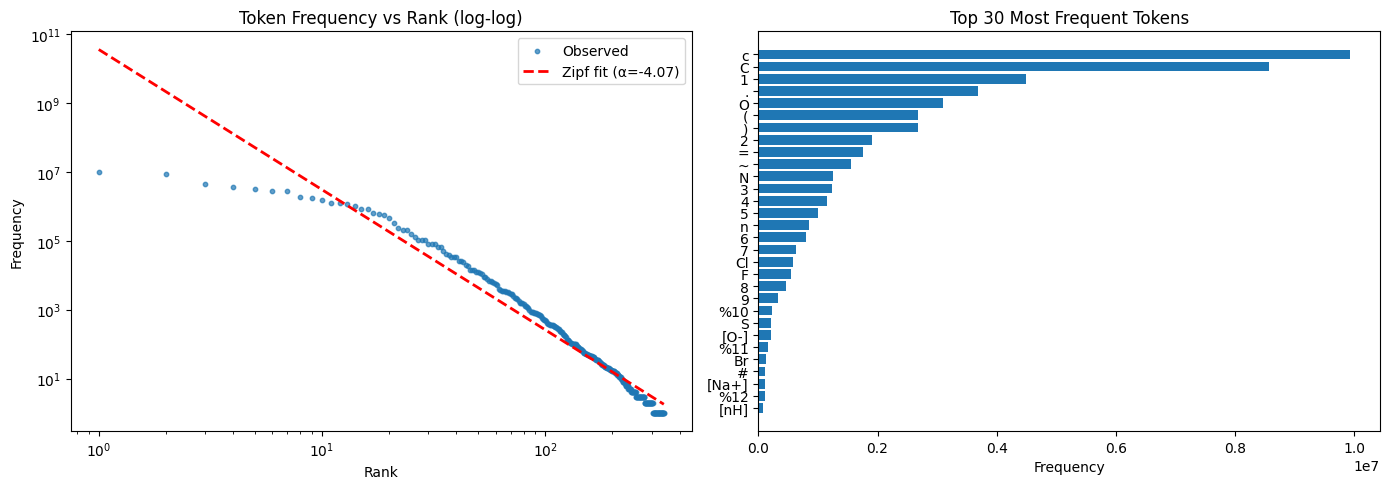


Total tokens: 51,413,853
Unique tokens: 340
Zipf exponent α: -4.07


In [38]:
# Zipf's Law Verification

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Count all tokens across both src and tgt training data
all_tokens = []
for col in ['tok_src', 'tok_tgt']:
    for line in train_df[col].values:
        all_tokens.extend(line.split())

counts = Counter(all_tokens)
# Sort by frequency (most common first)
sorted_counts = sorted(counts.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)
freqs = np.array(sorted_counts)

# Zipf's law: freq ∝ 1/rank → fit C/rank^alpha
# Log-log linear regression
log_ranks = np.log10(ranks)
log_freqs = np.log10(freqs)
alpha, log_C = np.polyfit(log_ranks, log_freqs, 1)
zipf_fit = 10**log_C * ranks**alpha

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Log-log frequency vs rank
axes[0].scatter(ranks, freqs, s=10, alpha=0.7, label='Observed')
axes[0].plot(ranks, zipf_fit, 'r--', linewidth=2, label=f'Zipf fit (α={alpha:.2f})')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Token Frequency vs Rank (log-log)')
axes[0].legend()

# Plot 2: Top 30 tokens bar chart
top_n = 30
top_tokens = counts.most_common(top_n)
tokens, token_freqs = zip(*top_tokens)
axes[1].barh(range(top_n), token_freqs)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(tokens)
axes[1].invert_yaxis()
axes[1].set_xlabel('Frequency')
axes[1].set_title(f'Top {top_n} Most Frequent Tokens')

plt.tight_layout()
plt.show()

print(f'\nTotal tokens: {len(all_tokens):,}')
print(f'Unique tokens: {len(counts)}')
print(f'Zipf exponent α: {alpha:.2f}')